## A simple madeup example showing $M_{local}$ computation

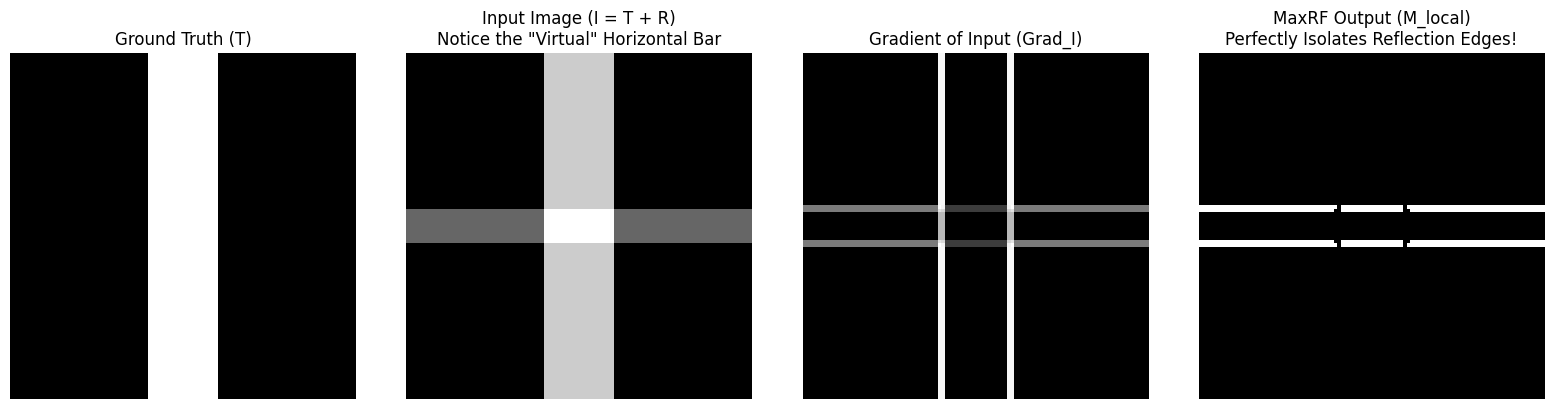

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel

# 1. Create a synthetic Ground Truth (T)
# A dark background with a bright vertical bar (the real object behind the glass)
T = np.zeros((100, 100))
T[:, 40:60] = 0.8  

# 2. Create a synthetic Reflection (R)
# A ghostly horizontal bar (the "virtual object" like a lamp behind the camera)
R = np.zeros((100, 100))
R[45:55, :] = 0.4  

# 3. Create the Input Image (I)
# The camera captures both the transmission and the reflection
I = T + R
I = np.clip(I, 0, 1) # Keep values valid

# 4. Compute the Sobel Gradients (as defined in the paper)
# We compute gradients in X and Y, then find the magnitude
def get_gradient(img):
    grad_x = sobel(img, axis=0)
    grad_y = sobel(img, axis=1)
    return np.hypot(grad_x, grad_y)

Grad_I = get_gradient(I)
Grad_T = get_gradient(T)

# 5. Apply the MaxRF Formula
# M_local = 1 if Grad(I) > Grad(T), else 0
M_local = (Grad_I > Grad_T).astype(float)

# --- Plotting the Results ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(T, cmap='gray')
axes[0].set_title('Ground Truth (T)')

axes[1].imshow(I, cmap='gray')
axes[1].set_title('Input Image (I = T + R)\nNotice the "Virtual" Horizontal Bar')

axes[2].imshow(Grad_I, cmap='gray')
axes[2].set_title('Gradient of Input (Grad_I)')

axes[3].imshow(M_local, cmap='gray')
axes[3].set_title('MaxRF Output (M_local)\nPerfectly Isolates Reflection Edges!')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---


# Structural similarity index

When comparing images, the mean squared error (MSE)--while simple to
implement--is not highly indicative of perceived similarity.  Structural
similarity aims to address this shortcoming by taking texture into account
[1]_, [2]_.

The example shows two modifications of the input image, each with the same MSE,
but with very different mean structural similarity indices.

.. [1] Zhou Wang; Bovik, A.C.; ,"Mean squared error: Love it or leave it? A new
       look at Signal Fidelity Measures," Signal Processing Magazine, IEEE,
       vol. 26, no. 1, pp. 98-117, Jan. 2009.

.. [2] Z. Wang, A. C. Bovik, H. R. Sheikh and E. P. Simoncelli, "Image quality
       assessment: From error visibility to structural similarity," IEEE
       Transactions on Image Processing, vol. 13, no. 4, pp. 600-612,
       Apr. 2004.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
from skimage import img_as_float

# Load image
path = "/home/amanr.mds2024/Developer/cv_proj/data/OpenRR100/blended/test_0003.jpg"
img = cv2.imread(path)

if img is None:
    raise ValueError("Image not found")

# Convert BGR -> RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to float [0,1]
img = img_as_float(img)

# Generate noise (same shape as image)
noise = np.ones_like(img) * 0.2 * (img.max() - img.min())
rng = np.random.default_rng()
noise[rng.random(size=noise.shape) > 0.5] *= -1

# Create variants
img_noise = img + noise
img_const = img + abs(noise)

# Clip to valid range
img_noise = np.clip(img_noise, 0, 1)
img_const = np.clip(img_const, 0, 1)

# ---- Metrics ----
mse_none = mean_squared_error(img, img)
ssim_none = ssim(img, img, data_range=1.0, channel_axis=2)

mse_noise = mean_squared_error(img, img_noise)
ssim_noise = ssim(img, img_noise, data_range=1.0, channel_axis=2)

mse_const = mean_squared_error(img, img_const)
ssim_const = ssim(img, img_const, data_range=1.0, channel_axis=2)

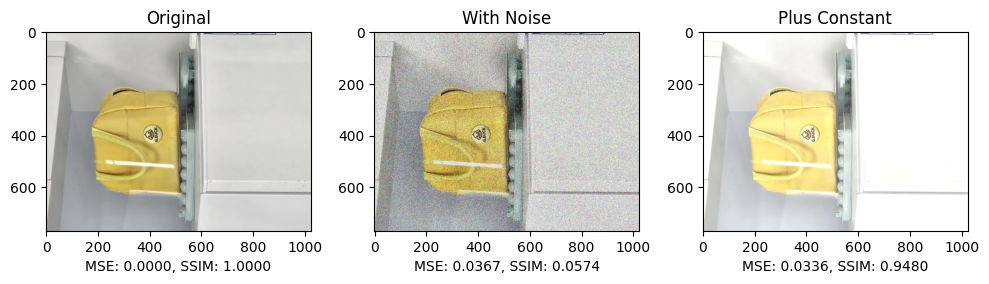

In [8]:
# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
ax = axes.ravel()

ax[0].imshow(img)
ax[0].set_title('Original')
ax[0].set_xlabel(f'MSE: {mse_none:.4f}, SSIM: {ssim_none:.4f}')
# ax[0].axis('off')

ax[1].imshow(img_noise)
ax[1].set_title('With Noise')
ax[1].set_xlabel(f'MSE: {mse_noise:.4f}, SSIM: {ssim_noise:.4f}')
# ax[1].axis('off')

ax[2].imshow(img_const)
ax[2].set_title('Plus Constant')
ax[2].set_xlabel(f'MSE: {mse_const:.4f}, SSIM: {ssim_const:.4f}')
# ax[2].axis('off')

plt.tight_layout()
plt.show()